In [1]:
# Import libraries needed for data handling, visualization, and modeling
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

In [2]:
# Load the anemia dataset
data = pd.read_excel("SKILICARSLAN_Anemia_DataSet.xlsx")
print("Shape:", data.shape)
data.head()

Shape: (15300, 29)


,GENDER,WBC,NE#,LY#,MO#,EO#,BA#,RBC,HGB,HCT,...,SDTSD,TSD,FERRITTE,FOLATE,B12,All_Class,HGB_Anemia_Class,Iron_anemia_Class,Folate_anemia_class,B12_Anemia_class
0,1,10.63,6.31,2.79,0.91,0.56,0.06,4.31,12.7,37.6,...,248.90,40.176778,194.00,5.06,178.2,4,0,0,0,1
1,1,5.08,2.50,1.87,0.43,0.26,0.02,4.34,12.8,36.9,...,348.48,33.482553,57.37,9.88,197.7,4,0,0,0,1
2,1,13.68,9.40,2.69,1.55,0.03,0.01,3.18,9.4,27.5,...,357.27,20.144429,114.20,8.37,143.0,4,0,0,0,1
3,1,5.60,3.94,0.83,0.54,0.26,0.03,3.35,10.5,31.4,...,360.60,27.731559,214.20,6.39,139.9,4,0,0,0,1
4,1,3.57,2.03,1.25,0.10,0.18,0.01,1.31,5.1,14.3,...,223.28,78.860623,303.40,4.30,50.0,4,0,0,0,1


In [3]:
# Clean the data: remove duplicates, cap outliers, and create the anemia target label
data = data.drop_duplicates().reset_index(drop=True)

lab_cols = ["WBC", "RBC", "HGB", "MCV", "MCH", "MCHC", "PLT", "FERRITTE", "FOLATE", "B12"]
for col in lab_cols:
    lower, upper = data[col].quantile(0.01), data[col].quantile(0.99)
    data[col] = data[col].clip(lower, upper)

data["Target"] = (data["All_Class"] != 0).astype(int)

print("Missing values remaining:", data.isnull().sum().sum())
print("Anemia prevalence: {:.1f}%".format(data["Target"].mean() * 100))

Missing values remaining: 0
Anemia prevalence: 36.4%


/tmp/ipykernel_478/2323597138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Target", data=data, ax=axes[0, 0], palette="Set2")
/tmp/ipykernel_478/2323597138.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["No Anemia", "Anemia"])
/tmp/ipykernel_478/2323597138.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y="HGB", data=data, ax=axes[0, 1], palette="Set2")
/tmp/ipykernel_478/2323597138.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["N

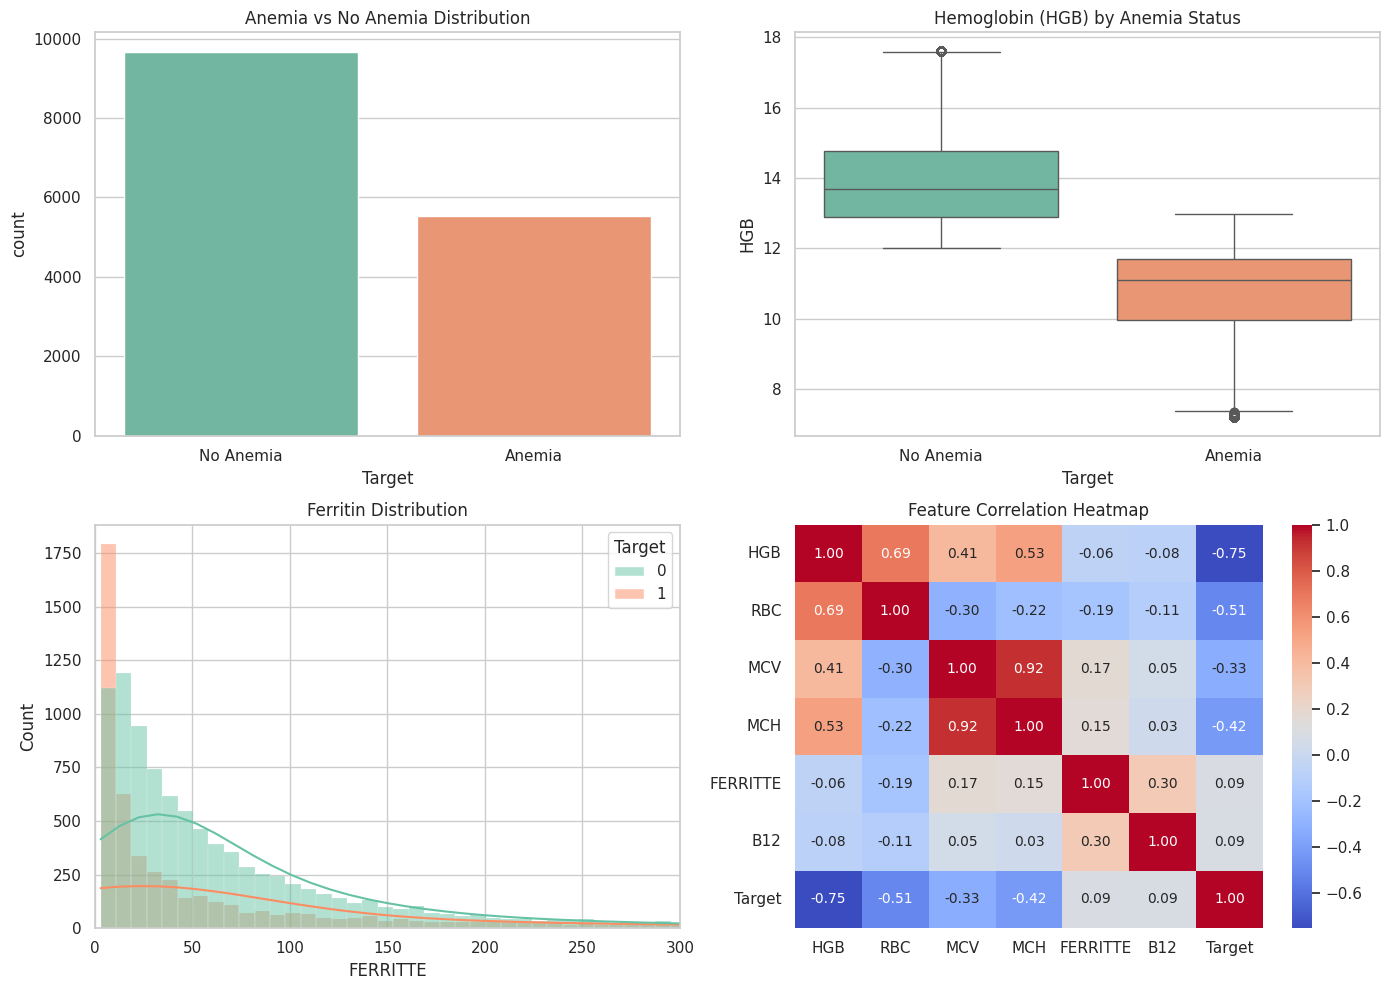

In [4]:
# Visualize anemia distribution, hemoglobin patterns, ferritin levels, and feature correlations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x="Target", data=data, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Anemia vs No Anemia Distribution")
axes[0, 0].set_xticklabels(["No Anemia", "Anemia"])

sns.boxplot(x="Target", y="HGB", data=data, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Hemoglobin (HGB) by Anemia Status")
axes[0, 1].set_xticklabels(["No Anemia", "Anemia"])

sns.histplot(data=data, x="FERRITTE", hue="Target", kde=True, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Ferritin Distribution")
axes[1, 0].set_xlim(0, 300)

key_cols = ["HGB", "RBC", "MCV", "MCH", "FERRITTE", "B12", "Target"]
sns.heatmap(data[key_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [5]:
# Split the data, scale features, and train Decision Tree and SVM models
features = ["GENDER", "WBC", "RBC", "MCV", "MCH", "MCHC", "RDW", "FERRITTE", "FOLATE", "B12"]

X = data[features]
y = data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dt_model = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("Both Decision Tree and SVM models trained successfully!")

Both Decision Tree and SVM models trained successfully!


In [6]:
# Calculate and compare performance metrics for both models
def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }


metrics_dt = get_metrics(y_test, y_pred_dt, y_prob_dt)
metrics_svm = get_metrics(y_test, y_pred_svm, y_prob_svm)

comparison_df = pd.DataFrame([metrics_dt, metrics_svm], index=["Decision Tree", "SVM"])
print("--- Model Performance Comparison ---")
print(comparison_df.round(4))

--- Model Performance Comparison ---
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree    0.9314     0.9009  0.9119    0.9064   0.9812
SVM              0.9734     0.9379  0.9928    0.9646   0.9985


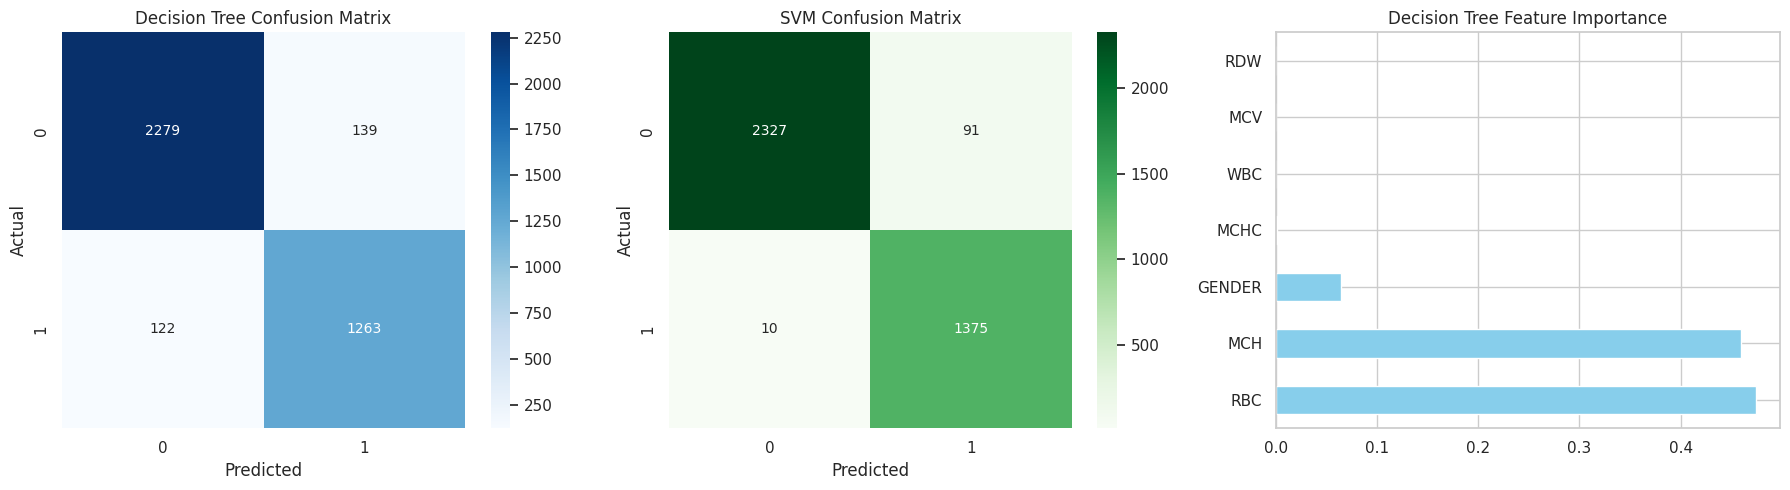

In [7]:
# Visualize confusion matrices for both models and Decision Tree feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Decision Tree Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("SVM Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

feat_importances = pd.Series(dt_model.feature_importances_, index=features)
feat_importances.nlargest(7).plot(kind="barh", ax=axes[2], color="skyblue")
axes[2].set_title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()